# Phase 1 sanity check: assembling and visualizing a 5-channel input tensor

This is the exit criterion for Phase 1 (data foundation): the dataloader pieces built so far need to produce a correctly normalized, co-registered 5-channel tensor, with correct ignore-index handling, and that has to be checked visually against the label -- not just asserted in a unit test.

**Why synthetic data:** the real Sen1Floods11 chips, Copernicus DEM tiles, and JRC occurrence layer aren't downloaded into this environment yet (that's a separate, later fetching step). So this notebook builds one fake-but-physically-plausible chip by hand -- a river, a separate flood event, and a no-data patch -- and runs it through every piece of `data/` built so far: `contract`, `terrain`, `hand`, `permanent_water`, and `normalization`. Every function called here is the real function, not a stand-in; only the input pixels are synthetic. Once real data exists on disk, the exact same code runs unmodified on it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

from data.contract import (
    CHIP_SIZE,
    LABEL_IGNORE,
    LABEL_NON_WATER,
    LABEL_WATER,
    validate_input_tensor,
    validate_label_tensor,
)
from data.hand import compute_hand
from data.normalization import NormalizationStats, apply_normalization, compute_normalization_stats
from data.permanent_water import compute_flood_extent, compute_permanent_water_mask
from data.terrain import compute_slope

rng = np.random.default_rng(seed=0)

## 1. Build a synthetic chip

The scene: a permanent river running down the middle (a valley in the DEM, and a channel with high JRC occurrence), plus a separate flooded patch elsewhere in the scene that is *not* part of the permanent river -- exactly the case the permanent-water subtraction exists to handle. A small corner is marked no-data, to exercise the ignore-index path.

SAR backscatter is simulated as low dB (dark) over water and higher dB over dry land, with Gaussian noise standing in for real SAR speckle.

In [2]:
size = CHIP_SIZE
pixel_size_m = 10.0
cols = np.arange(size)
rows = np.arange(size)
col_grid, row_grid = np.meshgrid(cols, rows)

# DEM: a valley with a river channel down the middle column, plus a gentle
# downstream slope so flow has somewhere to go (same shape as tests/test_hand.py,
# just scaled up to a real 512x512 chip).
dem = np.abs(col_grid - size // 2).astype(np.float64) * 2.0 + 50.0
dem += (size - row_grid) * 0.05

# JRC occurrence: high (permanent water) in a band around the river channel.
river_half_width = 3
near_river = np.abs(col_grid - size // 2) <= river_half_width
occurrence = np.where(near_river, 92.0, 4.0)

# A flood event away from the river -- this is what the permanent-water
# subtraction needs to correctly keep, while dropping the river itself.
blob_center = (size // 4, size // 4 * 3)
blob_radius = 40
dist_from_blob = np.sqrt((row_grid - blob_center[0]) ** 2 + (col_grid - blob_center[1]) ** 2)
flood_blob = dist_from_blob <= blob_radius

true_water = near_river | flood_blob

# Synthetic SAR backscatter: dark over water, brighter over dry land, plus speckle noise.
speckle = rng.normal(loc=0.0, scale=1.0, size=(size, size))
vv_db = np.where(true_water, -22.0, -9.0) + speckle
vh_db = np.where(true_water, -28.0, -15.0) + speckle * 0.8
vv_vh_ratio = vv_db / np.where(vh_db == 0, 1e-6, vh_db)

# Label from the same ground truth, plus a no-data corner to exercise the ignore index.
label = np.where(true_water, LABEL_WATER, LABEL_NON_WATER).astype(np.int64)
label[0:20, 0:20] = LABEL_IGNORE

print("true water pixels:", true_water.sum(), "/", size * size)

true water pixels: 8609 / 262144


## 2. Derive the terrain channels

`compute_slope` and `compute_hand` from `data/terrain.py` and `data/hand.py` -- the same functions covered by `tests/test_terrain.py` and `tests/test_hand.py` -- run directly on the synthetic DEM above.

The `accumulation_threshold` here was chosen the same way as in `tests/test_hand.py`: picked so only the true river channel (which accumulates flow from the *entire* width of the chip over many rows) gets marked as drainage, rather than a shorter false tributary elsewhere in the terrain. For a real DEM tile this needs to be tuned to the actual terrain, not reused as a magic constant.

In [3]:
slope = compute_slope(dem, pixel_size_m=pixel_size_m)
hand = compute_hand(dem, pixel_size_m=pixel_size_m, accumulation_threshold=255)

# compute_hand leaves the chip's outer border as NaN (a documented flow-routing
# edge effect -- see data/hand.py). Filled with 0 here only so the tensor below
# has no NaNs; a real pipeline resolves this by fetching DEM tiles with a padding
# buffer around each chip instead.
hand_filled = np.nan_to_num(hand, nan=0.0)

print("NaN fraction in raw HAND (border effect):", np.isnan(hand).mean())

NaN fraction in raw HAND (border effect): 0.0077972412109375


## 3. Assemble and validate the 5-channel tensor

Stack the channels in the exact order the data contract defines (`data/contract.py`), then run the same `validate_input_tensor` / `validate_label_tensor` checks that guard every other part of the pipeline. If any of the earlier steps produced the wrong shape, dtype, or an unexpected label value, this is where it would get caught.

In [4]:
input_tensor = np.stack([vv_db, vh_db, vv_vh_ratio, slope, hand_filled], axis=0).astype(np.float32)

validate_input_tensor(input_tensor)
validate_label_tensor(label)

print("input tensor:", input_tensor.shape, input_tensor.dtype)
print("label tensor:", label.shape, label.dtype)
print("contract validation passed")

input tensor: (5, 512, 512) float32
label tensor: (512, 512) int64
contract validation passed


## 4. Normalize, and prove the save/load round trip

In real training this only ever runs on the training split, and the resulting stats get persisted and reused everywhere else (see `data/normalization.py`). Here, with only one synthetic chip standing in for a whole training split, the save/load round trip is what actually matters to demonstrate -- that a stats file written to disk loads back byte-for-byte identical and normalizes the same way.

In [5]:
import tempfile
from pathlib import Path

stats = compute_normalization_stats([input_tensor])

with tempfile.TemporaryDirectory() as tmp_dir:
    stats_path = Path(tmp_dir) / "norm_stats.json"
    stats.save(stats_path)
    reloaded_stats = NormalizationStats.load(stats_path)
    assert reloaded_stats == stats, "round trip through disk changed the stats"

normalized = apply_normalization(input_tensor, stats)
print("per-channel mean after normalization (should be ~0):", normalized.mean(axis=(1, 2)))

per-channel mean after normalization (should be ~0): [-6.3329935e-08 -2.0861626e-07 -3.2782555e-07  1.7713755e-06
  1.6298145e-08]


## 5. Turn detected water into flood extent

This is the step the spec calls out as the whole point of the JRC layer: without it, the permanent river would show up as "flooded" on every single pass. `compute_flood_extent` should drop the river entirely while keeping the separate flood blob intact.

In [6]:
permanent_water_mask = compute_permanent_water_mask(occurrence)
detected_water = label == LABEL_WATER
flood_extent = compute_flood_extent(detected_water, permanent_water_mask)

river_core = np.abs(col_grid - size // 2) <= 1
print("flood extent correctly excludes the river core:", flood_extent[river_core].mean() == 0.0)
print("flood extent correctly keeps the flood blob:", flood_extent[flood_blob].mean() == 1.0)

flood extent correctly excludes the river core: True
flood extent correctly keeps the flood blob: True


## 6. Visualize everything

The actual sanity check: every channel, the label, and the derived masks, side by side, at the same pixel grid. The river should line up in the same place across every panel (co-registration), the ignore patch should be visible and distinct from real labels, and the flood-extent panel should show only the blob, not the river.

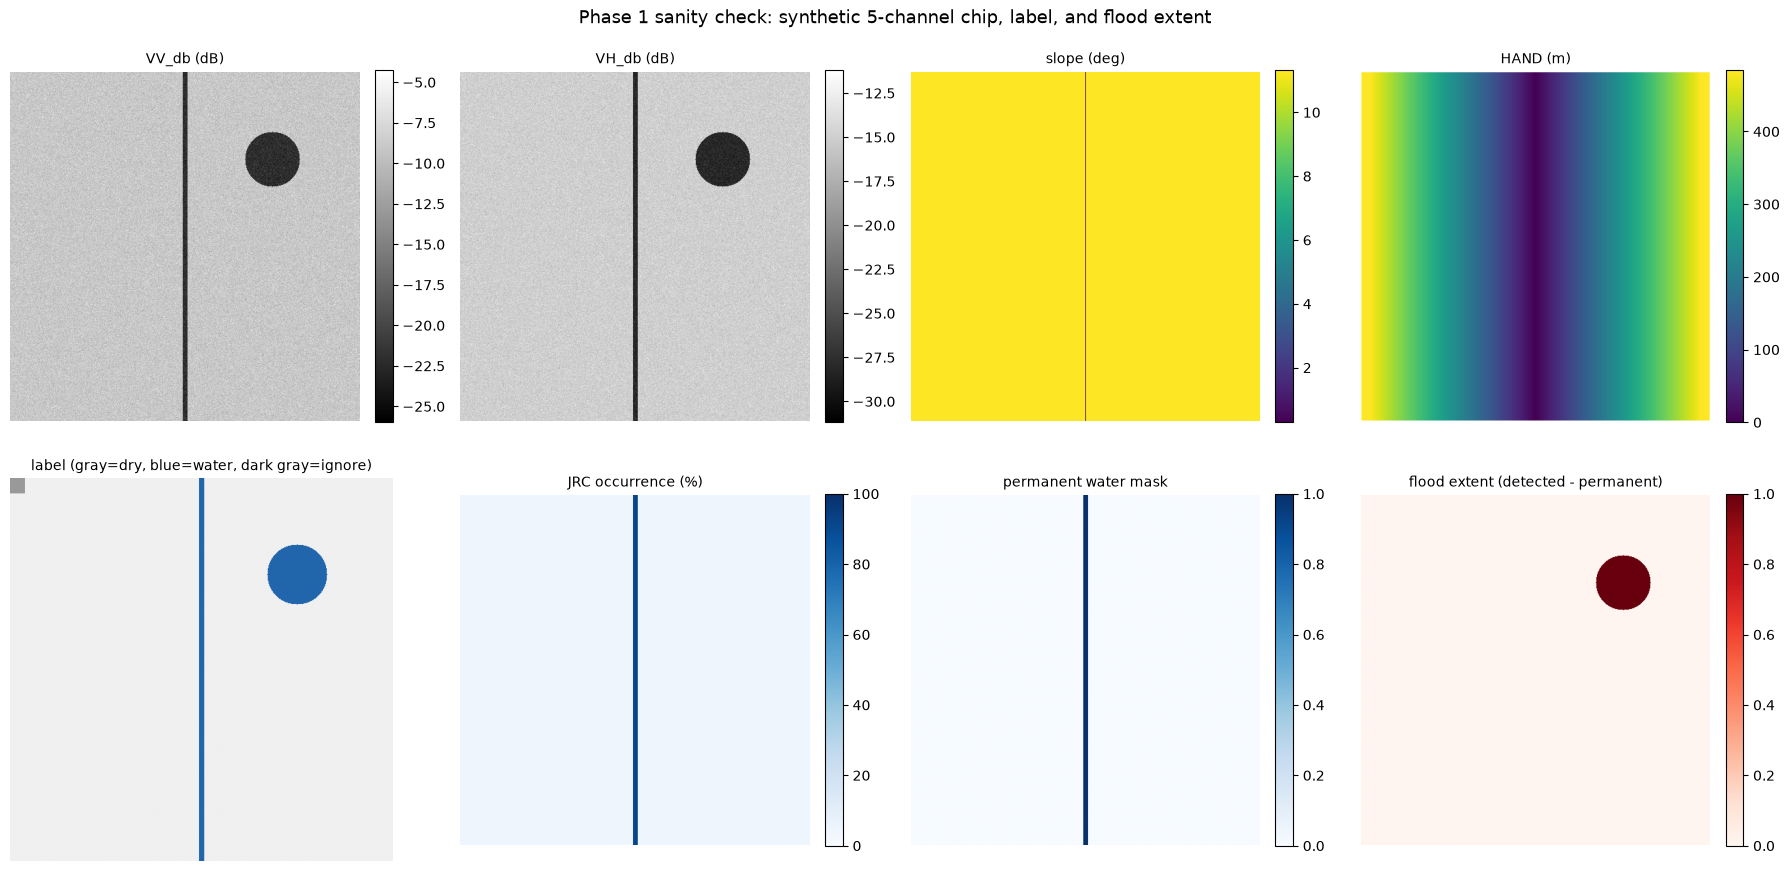

In [7]:
label_display = np.select(
    [label == LABEL_NON_WATER, label == LABEL_WATER, label == LABEL_IGNORE],
    [0, 1, 2],
)
label_cmap = ListedColormap(["#f0f0f0", "#2166ac", "#999999"])
label_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], label_cmap.N)
hand_vmax = float(np.nanpercentile(hand, 95))

panels = [
    ("VV_db (dB)", vv_db, dict(cmap="gray")),
    ("VH_db (dB)", vh_db, dict(cmap="gray")),
    ("slope (deg)", slope, dict(cmap="viridis")),
    ("HAND (m)", hand, dict(cmap="viridis", vmin=0, vmax=hand_vmax)),
    (
        "label (gray=dry, blue=water, dark gray=ignore)",
        label_display,
        dict(cmap=label_cmap, norm=label_norm),
    ),
    ("JRC occurrence (%)", occurrence, dict(cmap="Blues", vmin=0, vmax=100)),
    ("permanent water mask", permanent_water_mask, dict(cmap="Blues", vmin=0, vmax=1)),
    ("flood extent (detected - permanent)", flood_extent, dict(cmap="Reds", vmin=0, vmax=1)),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (title, data, kwargs) in zip(axes.flat, panels):
    im = ax.imshow(data, **kwargs)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    if "label" not in title:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Phase 1 sanity check: synthetic 5-channel chip, label, and flood extent", fontsize=13)
fig.tight_layout()
plt.show()